# Titanic Survival Analysis

## Project question

Which passenger characteristics were associated with survival on the Titanic, and how accurately can a small, interpretable classification model predict survival?

## CRISP-DM workflow

1. **Business Understanding:** define a reasonable survival-prediction question.
2. **Data Understanding:** inspect the data and explore important relationships.
3. **Data Preparation:** split the data, handle missing values, engineer features, encode categories, and scale numeric inputs without leakage.
4. **Modeling:** compare a majority baseline, logistic regression, Random Forest, Gradient Boosting, and a small neural network.
5. **Evaluation:** use five-fold cross-validation, then evaluate the selected logistic-regression model on the held-out validation set.
6. **Deployment/Communication:** save reproducible charts and tables for the README, article, and video.

This notebook follows the decisions made during the project. It does not tune models or change the selected final model.

In [19]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

OUTPUT_DIR = Path("titanic_notebook_outputs")
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"
CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def show_table(frame, rows=None):
    view = frame if rows is None else frame.head(rows)
    try:
        display(view)
    except NameError:
        print(view.to_string())

def save_show(fig, filename):
    fig.tight_layout()
    fig.savefig(CHART_DIR / filename, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

print(f"Outputs will be saved under: {OUTPUT_DIR}")

Outputs will be saved under: titanic_notebook_outputs


## 1. Data Understanding

The notebook searches for the original Kaggle file as `train.csv` beside the notebook or as `data/train.csv`. Its contents are not modified.

In [20]:
data_candidates = [
    Path("train.csv"),
    Path("data/train.csv"),
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place train.csv beside this notebook or under data/train.csv.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
show_table(df, 5)

Loaded: data/train.csv
Shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
inspection = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique(dropna=False),
})
inspection.to_csv(TABLE_DIR / "dataset_inspection.csv")
print(f"Duplicate rows: {df.duplicated().sum()}")
show_table(inspection)

missing_table = (
    df.isna().sum().rename("Missing values").to_frame()
    .assign(Percent=lambda x: 100 * x["Missing values"] / len(df))
    .sort_values("Missing values", ascending=False)
)
missing_table.to_csv(TABLE_DIR / "missing_values.csv")
show_table(missing_table[missing_table["Missing values"] > 0])

Duplicate rows: 0


,Data type,Missing values,Unique values
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,object,0,891
Sex,object,0,2
Age,float64,177,89
SibSp,int64,0,7
Parch,int64,0,7
Ticket,object,0,681
Fare,float64,0,248


,Missing values,Percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


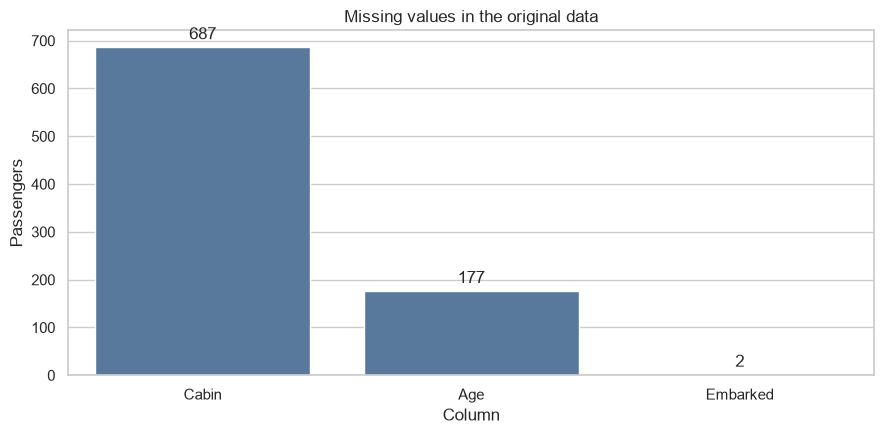

,Outcome,Passengers,Percentage
0,Did not survive,549,61.616162
1,Survived,342,38.383838


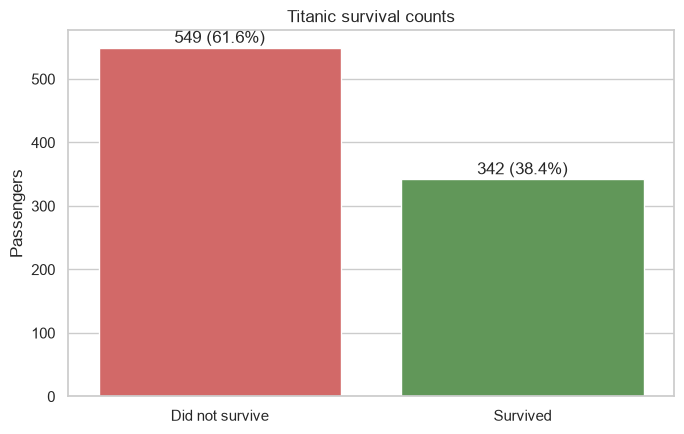

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
missing_plot = missing_table[missing_table["Missing values"] > 0].reset_index()
sns.barplot(data=missing_plot, x="index", y="Missing values", color="#4C78A8", ax=ax)
ax.set(title="Missing values in the original data", xlabel="Column", ylabel="Passengers")
for container in ax.containers:
    ax.bar_label(container, padding=3)
save_show(fig, "01_missing_values.png")

survival_summary = df["Survived"].value_counts().sort_index().rename_axis("Survived").reset_index(name="Passengers")
survival_summary["Percentage"] = 100 * survival_summary["Passengers"] / len(df)
survival_summary["Outcome"] = survival_summary["Survived"].map({0: "Did not survive", 1: "Survived"})
survival_summary.to_csv(TABLE_DIR / "survival_counts_percentages.csv", index=False)
show_table(survival_summary[["Outcome", "Passengers", "Percentage"]])

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=survival_summary, x="Outcome", y="Passengers", hue="Outcome", legend=False,
            palette=["#E45756", "#59A14F"], ax=ax)
ax.set(title="Titanic survival counts", xlabel="", ylabel="Passengers")
for i, row in survival_summary.iterrows():
    ax.text(i, row["Passengers"] + 8, f"{row['Passengers']} ({row['Percentage']:.1f}%)", ha="center")
save_show(fig, "02_survival_counts_percentages.png")

### Core EDA

The following charts reproduce the completed EDA using only the original data. Survival rates are descriptive associations, not causal effects.

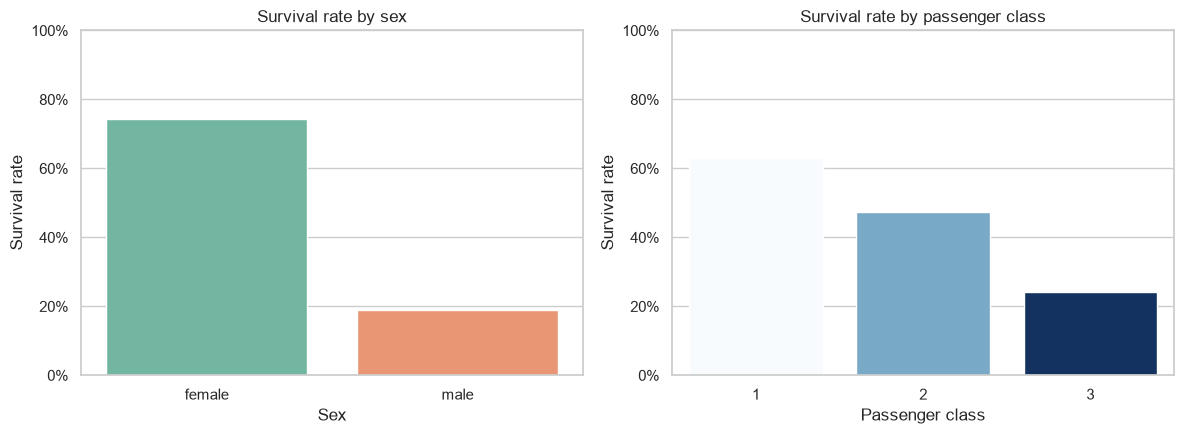

In [23]:
sex_summary = df.groupby("Sex")["Survived"].agg(Passengers="size", SurvivalRate="mean").reset_index()
class_summary = df.groupby("Pclass")["Survived"].agg(Passengers="size", SurvivalRate="mean").reset_index()
sex_summary.to_csv(TABLE_DIR / "survival_by_sex.csv", index=False)
class_summary.to_csv(TABLE_DIR / "survival_by_pclass.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=sex_summary, x="Sex", y="SurvivalRate", hue="Sex", legend=False, ax=axes[0], palette="Set2")
sns.barplot(data=class_summary, x="Pclass", y="SurvivalRate", hue="Pclass", legend=False, ax=axes[1], palette="Blues")
axes[0].set(title="Survival rate by sex", xlabel="Sex", ylabel="Survival rate", ylim=(0, 1))
axes[1].set(title="Survival rate by passenger class", xlabel="Passenger class", ylabel="Survival rate", ylim=(0, 1))
for ax in axes:
    ax.yaxis.set_major_formatter(lambda value, pos: f"{value:.0%}")
save_show(fig, "03_survival_by_sex_and_class.png")

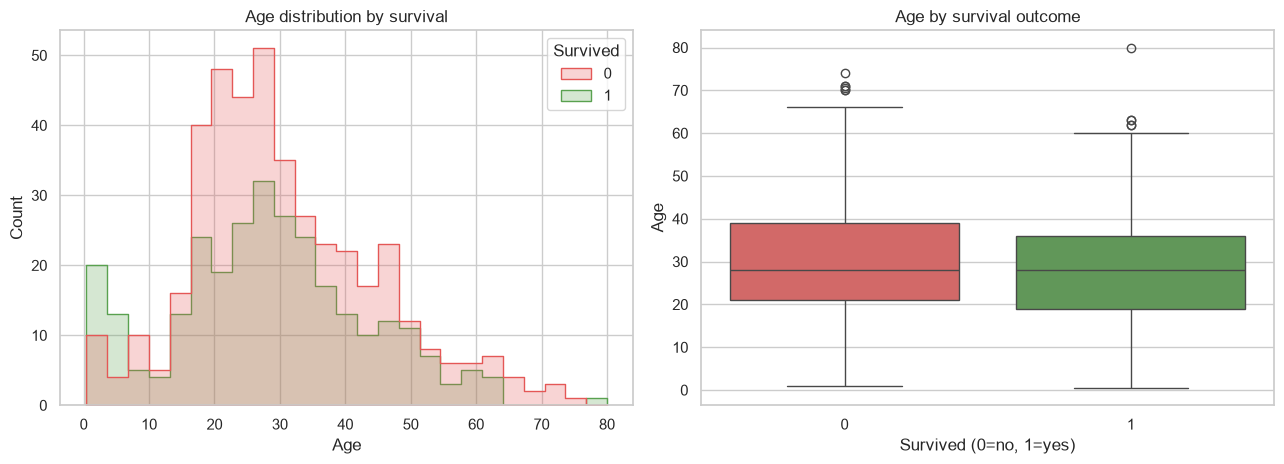

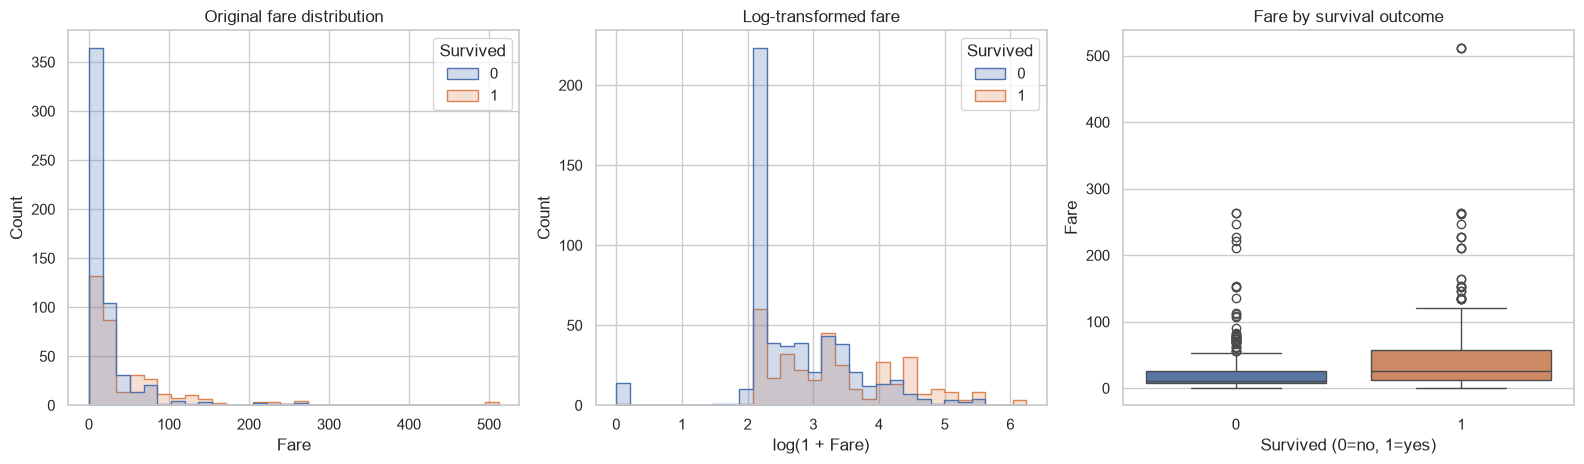

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(data=df, x="Age", hue="Survived", bins=25, element="step", stat="count",
             common_norm=False, palette={0: "#E45756", 1: "#59A14F"}, ax=axes[0])
sns.boxplot(data=df, x="Survived", y="Age", hue="Survived", legend=False,
            palette={0: "#E45756", 1: "#59A14F"}, ax=axes[1])
axes[0].set_title("Age distribution by survival")
axes[1].set(title="Age by survival outcome", xlabel="Survived (0=no, 1=yes)")
save_show(fig, "04_age_by_survival.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.histplot(data=df, x="Fare", hue="Survived", bins=30, element="step", ax=axes[0])
sns.histplot(x=np.log1p(df["Fare"]), hue=df["Survived"], bins=30, element="step", ax=axes[1])
sns.boxplot(data=df, x="Survived", y="Fare", hue="Survived", legend=False, ax=axes[2])
axes[0].set_title("Original fare distribution")
axes[1].set(title="Log-transformed fare", xlabel="log(1 + Fare)")
axes[2].set(title="Fare by survival outcome", xlabel="Survived (0=no, 1=yes)")
save_show(fig, "05_fare_by_survival.png")

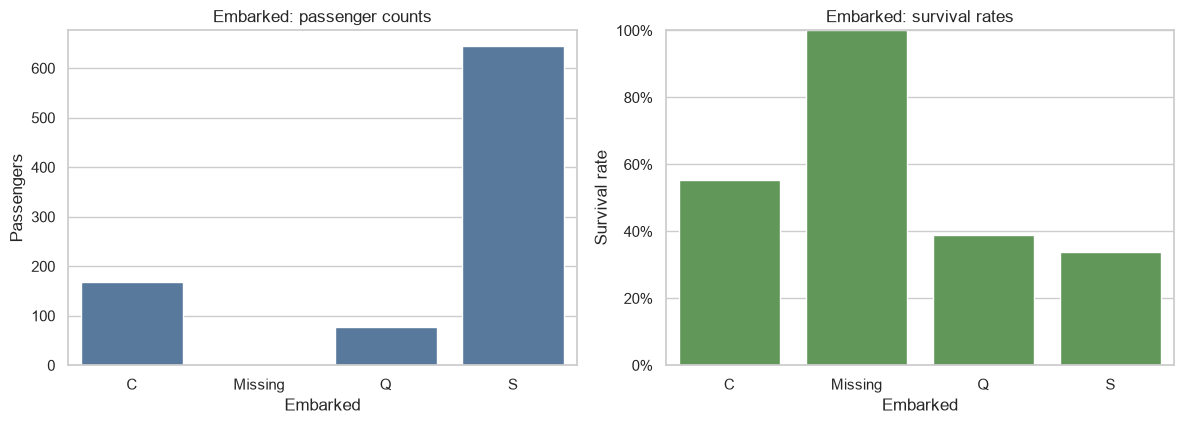

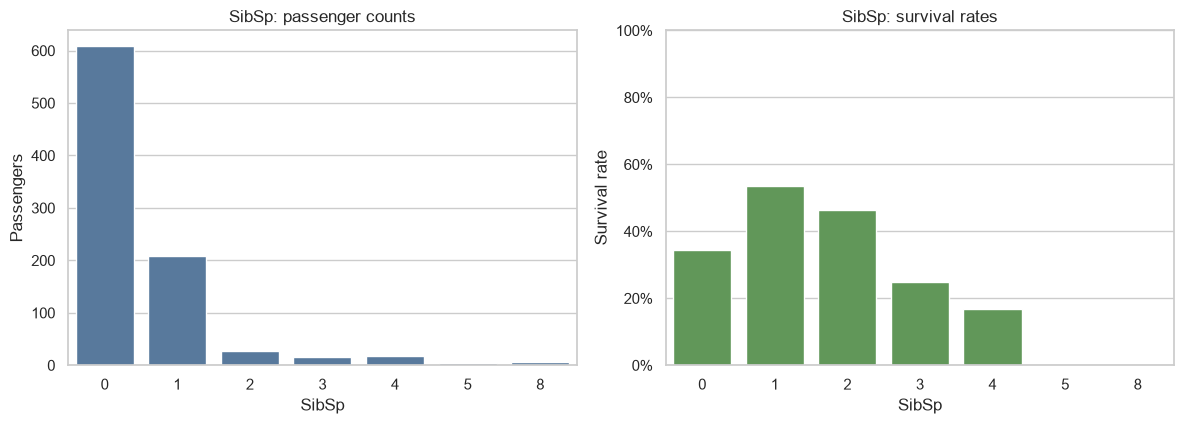

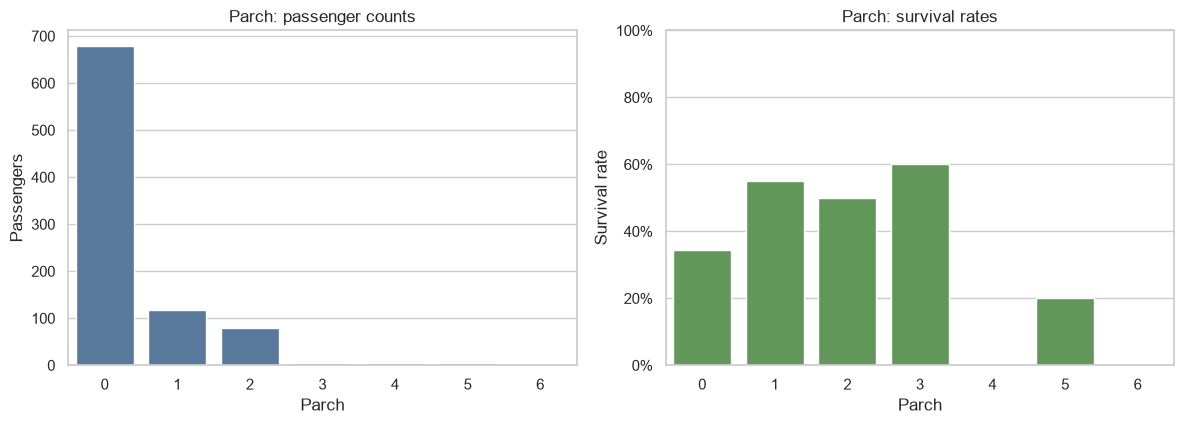

In [25]:
def count_rate_table(column):
    labels = df[column].astype("object").where(df[column].notna(), "Missing")
    table = df.assign(Group=labels).groupby("Group", dropna=False)["Survived"].agg(
        Passengers="size", SurvivalRate="mean"
    ).reset_index()
    return table

def plot_count_rate(column, filename, title):
    table = count_rate_table(column)
    table.to_csv(TABLE_DIR / f"{column.lower()}_counts_survival_rates.csv", index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    sns.barplot(data=table, x="Group", y="Passengers", color="#4C78A8", ax=axes[0])
    sns.barplot(data=table, x="Group", y="SurvivalRate", color="#59A14F", ax=axes[1])
    axes[0].set(title=f"{title}: passenger counts", xlabel=title, ylabel="Passengers")
    axes[1].set(title=f"{title}: survival rates", xlabel=title, ylabel="Survival rate", ylim=(0, 1))
    axes[1].yaxis.set_major_formatter(lambda value, pos: f"{value:.0%}")
    save_show(fig, filename)
    return table

embarked_summary = plot_count_rate("Embarked", "06_embarked_counts_survival.png", "Embarked")
sibsp_summary = plot_count_rate("SibSp", "07_sibsp_counts_survival.png", "SibSp")
parch_summary = plot_count_rate("Parch", "08_parch_counts_survival.png", "Parch")

,Sex,Pclass,Passengers,SurvivalRate
0,female,1,94,0.968085
1,female,2,76,0.921053
2,female,3,144,0.500000
3,male,1,122,0.368852
4,male,2,108,0.157407
5,male,3,347,0.135447


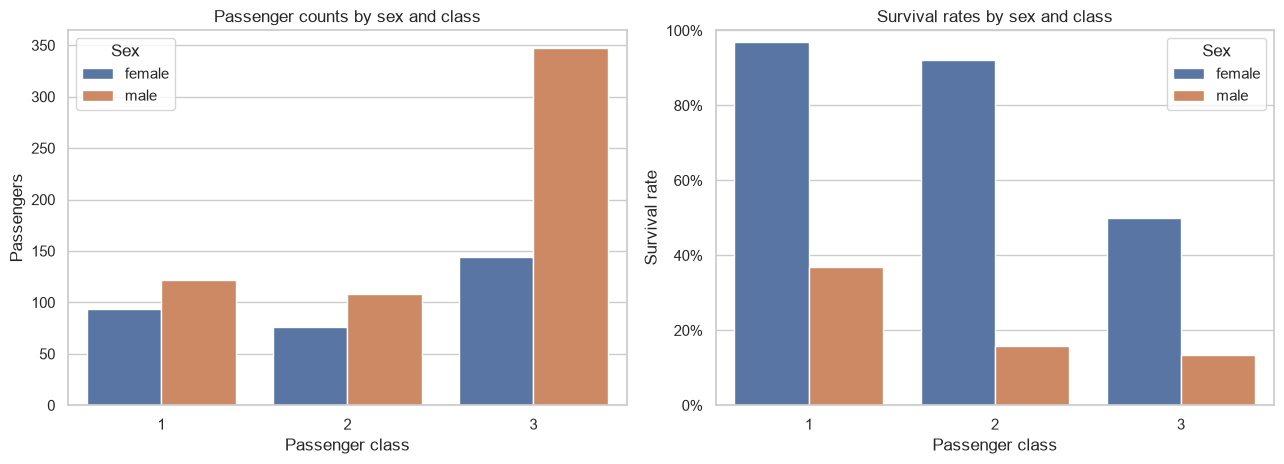

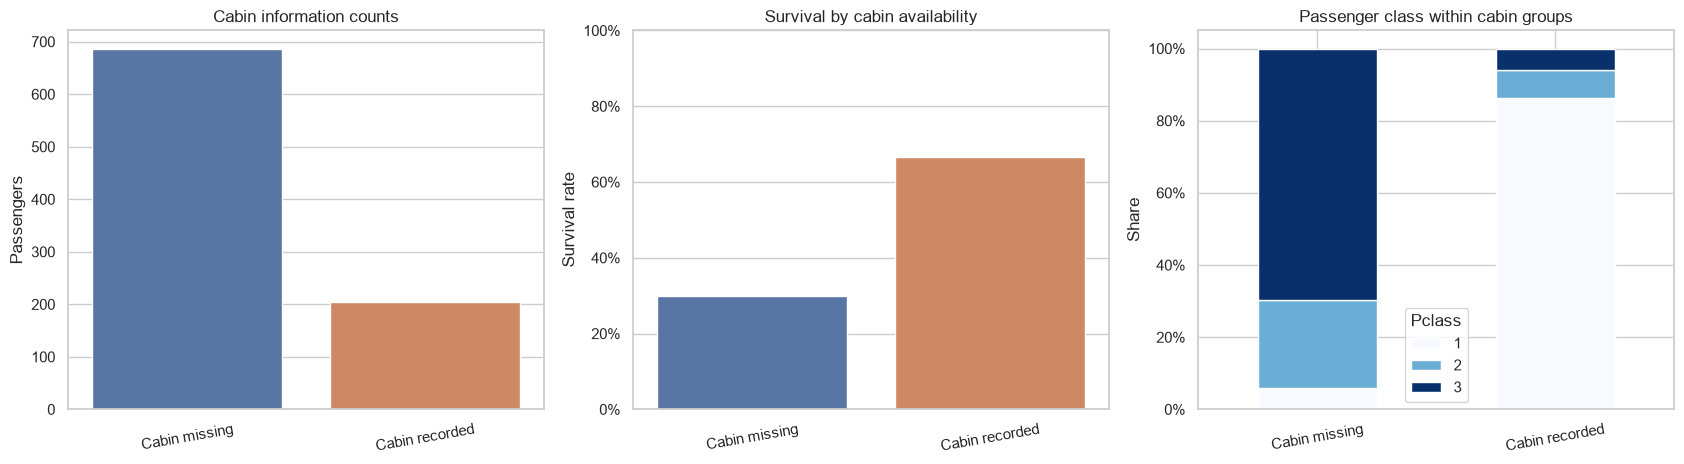

In [26]:
sex_class_summary = df.groupby(["Sex", "Pclass"])["Survived"].agg(
    Passengers="size", SurvivalRate="mean"
).reset_index()
sex_class_summary.to_csv(TABLE_DIR / "sex_pclass_counts_survival_rates.csv", index=False)
show_table(sex_class_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=sex_class_summary, x="Pclass", y="Passengers", hue="Sex", ax=axes[0])
sns.barplot(data=sex_class_summary, x="Pclass", y="SurvivalRate", hue="Sex", ax=axes[1])
axes[0].set(title="Passenger counts by sex and class", xlabel="Passenger class")
axes[1].set(title="Survival rates by sex and class", xlabel="Passenger class", ylabel="Survival rate", ylim=(0, 1))
axes[1].yaxis.set_major_formatter(lambda value, pos: f"{value:.0%}")
save_show(fig, "09_sex_and_class_together.png")

cabin_eda = df.assign(CabinStatus=np.where(df["Cabin"].notna(), "Cabin recorded", "Cabin missing"))
cabin_summary = cabin_eda.groupby("CabinStatus")["Survived"].agg(Passengers="size", SurvivalRate="mean").reset_index()
cabin_class = pd.crosstab(cabin_eda["CabinStatus"], cabin_eda["Pclass"], normalize="index")
cabin_summary.to_csv(TABLE_DIR / "cabin_counts_survival_rates.csv", index=False)
cabin_class.to_csv(TABLE_DIR / "cabin_class_distribution.csv")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.barplot(data=cabin_summary, x="CabinStatus", y="Passengers", hue="CabinStatus", legend=False, ax=axes[0])
sns.barplot(data=cabin_summary, x="CabinStatus", y="SurvivalRate", hue="CabinStatus", legend=False, ax=axes[1])
cabin_class.plot(kind="bar", stacked=True, ax=axes[2], colormap="Blues")
axes[0].set(title="Cabin information counts", xlabel="", ylabel="Passengers")
axes[1].set(title="Survival by cabin availability", xlabel="", ylabel="Survival rate", ylim=(0, 1))
axes[1].yaxis.set_major_formatter(lambda value, pos: f"{value:.0%}")
axes[2].set(title="Passenger class within cabin groups", xlabel="", ylabel="Share")
axes[2].yaxis.set_major_formatter(lambda value, pos: f"{value:.0%}")
axes[2].legend(title="Pclass")
for ax in axes:
    ax.tick_params(axis="x", rotation=10)
save_show(fig, "10_cabin_information.png")

### EDA summary

Women and higher-class passengers had much higher observed survival rates. Fare was strongly right-skewed and was transformed with `log1p`. Age had many missing values and showed overlapping survivor/non-survivor distributions. Cabin availability was strongly connected with passenger class, so it was retained only as a cautious `CabinKnown` indicator. Family-count variables showed nonlinear patterns, motivating `FamilySize` and `IsAlone`.

## 2. Data Preparation

The split is made **before** learned preparation. This prevents validation information from determining imputation values, title groups, category encoding, or scaling parameters.

In [27]:
X = df.drop(columns=["Survived", "PassengerId"])
y = df["Survived"].copy()
passenger_ids = df["PassengerId"].copy()

X_train, X_validation, y_train, y_validation, id_train, id_validation = train_test_split(
    X, y, passenger_ids,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

# Preserve original source-row order within each split, matching the project files.
train_order = X_train.index.sort_values()
validation_order = X_validation.index.sort_values()
X_train, y_train, id_train = X_train.loc[train_order], y_train.loc[train_order], id_train.loc[train_order]
X_validation, y_validation, id_validation = (
    X_validation.loc[validation_order], y_validation.loc[validation_order], id_validation.loc[validation_order]
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation"],
    "Rows": [len(X_train), len(X_validation)],
    "Survival percentage": [100 * y_train.mean(), 100 * y_validation.mean()],
})
split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)
show_table(split_summary)

,Split,Rows,Survival percentage
0,Training,712,38.342697
1,Validation,179,38.547486


In [28]:
age_fill = X_train["Age"].median()
embarked_fill = X_train["Embarked"].mode().iloc[0]
fare_fill = X_train["Fare"].median()

preparation_decisions = pd.DataFrame([
    ["Age", f"Training median ({age_fill:g})"],
    ["Embarked", f"Training mode ({embarked_fill})"],
    ["Fare", f"Training median fallback ({fare_fill:.4f}) before FareLog"],
    ["Cabin", "Do not guess; create CabinKnown and remove raw Cabin"],
    ["Fare", "Keep FareLog; remove raw Fare"],
    ["SibSp, Parch", "Replace with FamilySize and IsAlone"],
    ["Name", "Extract Title, then remove raw Name"],
    ["Ticket", "Remove high-cardinality identifier"],
    ["Pclass", "Treat as categorical and one-hot encode"],
], columns=["Item", "Decision"])
preparation_decisions.to_csv(TABLE_DIR / "data_preparation_decisions.csv", index=False)
show_table(preparation_decisions)

,Item,Decision
0,Age,Training median (28.5)
1,Embarked,Training mode (S)
2,Fare,Training median fallback (14.4542) before FareLog
3,Cabin,Do not guess; create CabinKnown and remove raw...
4,Fare,Keep FareLog; remove raw Fare
5,"SibSp, Parch",Replace with FamilySize and IsAlone
6,Name,"Extract Title, then remove raw Name"
7,Ticket,Remove high-cardinality identifier
8,Pclass,Treat as categorical and one-hot encode


In [29]:
TITLE_NORMALIZATION = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
NUMERIC_COLUMNS = ["Age", "FareLog", "CabinKnown", "FamilySize", "IsAlone"]
CATEGORICAL_COLUMNS = ["Pclass", "Sex", "Embarked", "Title"]
FINAL_COLUMNS = ["Pclass", "Sex", "Age", "FareLog", "Embarked", "CabinKnown", "FamilySize", "IsAlone", "Title"]

class TitanicFeatureBuilder(BaseEstimator, TransformerMixin):
    # Create the agreed features; title groups are learned during fit.

    def __init__(self, rare_title_threshold=10):
        self.rare_title_threshold = rare_title_threshold

    @staticmethod
    def _normalized_titles(names):
        titles = names.str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
        return titles.replace(TITLE_NORMALIZATION)

    def fit(self, X, y=None):
        counts = self._normalized_titles(X["Name"]).value_counts()
        self.common_titles_ = set(counts[counts >= self.rare_title_threshold].index)
        return self

    def transform(self, X):
        check_is_fitted(self, "common_titles_")
        result = pd.DataFrame(index=X.index)
        result["Pclass"] = X["Pclass"]
        result["Sex"] = X["Sex"]
        result["Age"] = X["Age"]
        result["FareLog"] = np.log1p(X["Fare"])
        result["Embarked"] = X["Embarked"]
        result["CabinKnown"] = X["Cabin"].notna().astype("int8")
        result["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        result["IsAlone"] = (result["FamilySize"] == 1).astype("int8")
        titles = self._normalized_titles(X["Name"])
        result["Title"] = titles.where(titles.isin(self.common_titles_), "Rare")
        return result[FINAL_COLUMNS]

feature_builder_preview = TitanicFeatureBuilder(rare_title_threshold=10).fit(X_train)
prepared_preview = feature_builder_preview.transform(X_train).head()
print("Common training titles:", sorted(feature_builder_preview.common_titles_))
print("Final columns:", FINAL_COLUMNS)
show_table(prepared_preview)

Common training titles: ['Master', 'Miss', 'Mr', 'Mrs']
Final columns: ['Pclass', 'Sex', 'Age', 'FareLog', 'Embarked', 'CabinKnown', 'FamilySize', 'IsAlone', 'Title']


,Pclass,Sex,Age,FareLog,Embarked,CabinKnown,FamilySize,IsAlone,Title
0,3,male,22.0,2.110213,S,0,2,0,Mr
1,1,female,38.0,4.280593,C,1,2,0,Mrs
2,3,female,26.0,2.188856,S,0,1,1,Miss
3,1,female,35.0,3.990834,S,1,2,0,Mrs
5,3,male,NaN,2.246893,Q,0,1,1,Mr


The final feature set contains nine fields. Numeric values are median-imputed and scaled; categorical values are mode-imputed and one-hot encoded. Every learned step is placed inside a pipeline for cross-validation.

In [30]:
def build_pipeline(model, dense_categories=False):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense_categories)),
    ])
    preparation = ColumnTransformer([
        ("numeric", numeric_pipeline, NUMERIC_COLUMNS),
        ("categorical", categorical_pipeline, CATEGORICAL_COLUMNS),
    ])
    return Pipeline([
        ("feature_builder", TitanicFeatureBuilder(rare_title_threshold=10)),
        ("preparation", preparation),
        ("model", model),
    ])

def logistic_pipeline():
    return build_pipeline(LogisticRegression(max_iter=1000, random_state=42))

def forest_pipeline():
    return build_pipeline(RandomForestClassifier(random_state=42, n_jobs=-1))

def gradient_pipeline():
    return build_pipeline(GradientBoostingClassifier(random_state=42), dense_categories=True)

def neural_pipeline():
    return build_pipeline(
        MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, early_stopping=True, random_state=42),
        dense_categories=True,
    )

## 3. Modeling and Five-Fold Cross-Validation

The four models use fixed, untuned settings. Five-fold stratified cross-validation is performed on the training partition only. The held-out validation data are not used in this comparison.

In [31]:
model_pipelines = {
    "Logistic regression": logistic_pipeline(),
    "Random Forest": forest_pipeline(),
    "Gradient Boosting": gradient_pipeline(),
    "Small neural network": neural_pipeline(),
}
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
cv_fold_tables = []

for model_name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=folds,
        scoring=["accuracy", "f1", "roc_auc"],
        error_score="raise", return_train_score=False,
    )
    fold_table = pd.DataFrame({
        "Model": model_name,
        "Fold": np.arange(1, 6),
        "Accuracy": scores["test_accuracy"],
        "F1": scores["test_f1"],
        "ROC-AUC": scores["test_roc_auc"],
    })
    cv_fold_tables.append(fold_table)
    cv_rows.append({
        "Model": model_name,
        "Accuracy mean": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(ddof=0),
        "F1 mean": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(ddof=0),
        "ROC-AUC mean": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(ddof=0),
    })

cv_comparison = pd.DataFrame(cv_rows)
cv_fold_scores = pd.concat(cv_fold_tables, ignore_index=True)
cv_comparison.to_csv(TABLE_DIR / "five_fold_model_comparison.csv", index=False)
cv_fold_scores.to_csv(TABLE_DIR / "five_fold_scores.csv", index=False)
show_table(cv_comparison.round(4))

,Model,Accuracy mean,Accuracy SD,F1 mean,F1 SD,ROC-AUC mean,ROC-AUC SD
0,Logistic regression,0.8244,0.0207,0.7678,0.0195,0.8743,0.0153
1,Random Forest,0.8174,0.0098,0.7558,0.0195,0.8696,0.0163
2,Gradient Boosting,0.8343,0.0156,0.7687,0.0280,0.8940,0.0208
3,Small neural network,0.7162,0.0701,0.5767,0.1019,0.7678,0.0963


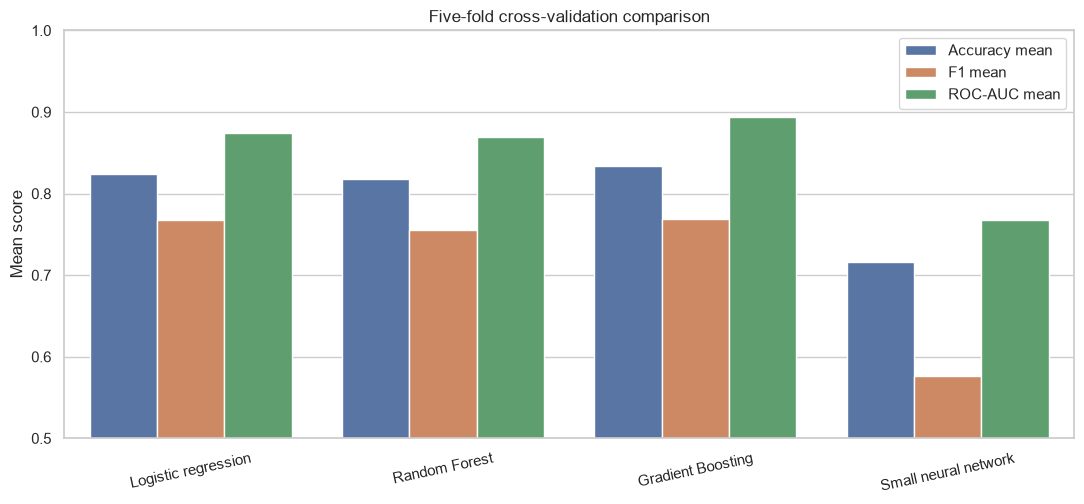

In [32]:
plot_cv = cv_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy mean", "F1 mean", "ROC-AUC mean"],
    var_name="Metric", value_name="Mean score",
)
fig, ax = plt.subplots(figsize=(11, 5.2))
sns.barplot(data=plot_cv, x="Model", y="Mean score", hue="Metric", ax=ax)
ax.set(title="Five-fold cross-validation comparison", xlabel="", ylabel="Mean score", ylim=(0.5, 1.0))
ax.tick_params(axis="x", rotation=12)
ax.legend(title="")
save_show(fig, "11_cross_validation_comparison.png")

Gradient Boosting had the highest cross-validation accuracy and ROC-AUC. Logistic regression had nearly the same mean F1, lower F1 and ROC-AUC variation, and much clearer coefficients. The small neural network was unstable and performed poorly for this small dataset.

## 4. Final Held-Out Evaluation

The majority-class baseline and logistic regression are evaluated on the untouched validation partition. Gradient Boosting is also shown because it was the provisional CV winner evaluated during the original workflow. No threshold or model setting is changed after seeing these results.

In [33]:
def metric_row(name, actual, predicted, probability):
    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1": f1_score(actual, predicted, zero_division=0),
        "ROC-AUC": roc_auc_score(actual, probability),
    }

baseline = Pipeline([
    ("feature_builder", TitanicFeatureBuilder(rare_title_threshold=10)),
    ("preparation", ColumnTransformer([
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), NUMERIC_COLUMNS),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_COLUMNS),
    ])),
    ("model", DummyClassifier(strategy="most_frequent")),
])
final_logistic = logistic_pipeline()
validation_gradient = gradient_pipeline()

evaluation_rows = []
validation_outputs = {}
for name, model in [
    ("Majority-class baseline", baseline),
    ("Logistic regression", final_logistic),
    ("Gradient Boosting", validation_gradient),
]:
    model.fit(X_train, y_train)
    predictions = model.predict(X_validation)
    probabilities = model.predict_proba(X_validation)[:, 1]
    evaluation_rows.append(metric_row(name, y_validation, predictions, probabilities))
    validation_outputs[name] = (predictions, probabilities)

validation_metrics = pd.DataFrame(evaluation_rows)
validation_metrics.to_csv(TABLE_DIR / "held_out_validation_metrics.csv", index=False)
show_table(validation_metrics.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority-class baseline,0.6145,0.0000,0.0000,0.0000,0.5000
1,Logistic regression,0.8268,0.7879,0.7536,0.7704,0.8653
2,Gradient Boosting,0.8101,0.7869,0.6957,0.7385,0.8409


,Predicted: did not survive,Predicted: survived
Actual: did not survive,96,14
Actual: survived,17,52


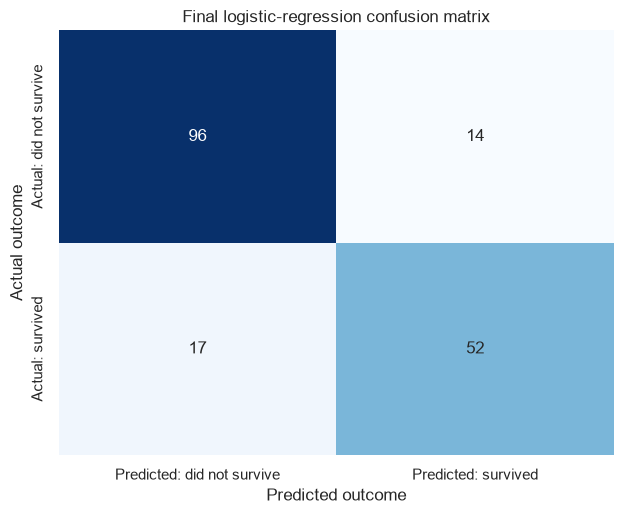

In [34]:
logistic_predictions, logistic_probabilities = validation_outputs["Logistic regression"]
logistic_matrix = confusion_matrix(y_validation, logistic_predictions, labels=[0, 1])
confusion_table = pd.DataFrame(
    logistic_matrix,
    index=["Actual: did not survive", "Actual: survived"],
    columns=["Predicted: did not survive", "Predicted: survived"],
)
confusion_table.to_csv(TABLE_DIR / "logistic_confusion_matrix.csv")
show_table(confusion_table)

fig, ax = plt.subplots(figsize=(6.4, 5.3))
sns.heatmap(confusion_table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set(title="Final logistic-regression confusion matrix", xlabel="Predicted outcome", ylabel="Actual outcome")
save_show(fig, "12_logistic_confusion_matrix.png")

### Final decision

**Logistic regression remains the final model.** It achieved 82.68% accuracy, 77.04% F1, and 0.8653 ROC-AUC on held-out validation—better than Gradient Boosting on every validation metric. Its validation results were also close to its cross-validation estimates, and its coefficients support direct interpretation.

## 5. Feature Interpretation and Errors

Positive coefficients push predictions toward survival; negative coefficients push them toward not surviving. Numeric coefficients refer to a one-standard-deviation change because numeric columns were scaled.

Largest positive coefficients


,Feature,Coefficient
13,categorical__Title_Master,1.230
8,categorical__Sex_female,0.832
16,categorical__Title_Mrs,0.584
2,numeric__CabinKnown,0.467
1,numeric__FareLog,0.438


Largest negative coefficients


,Feature,Coefficient
15,categorical__Title_Mr,-1.243
9,categorical__Sex_male,-0.752
3,numeric__FamilySize,-0.741
7,categorical__Pclass_3,-0.462
0,numeric__Age,-0.397


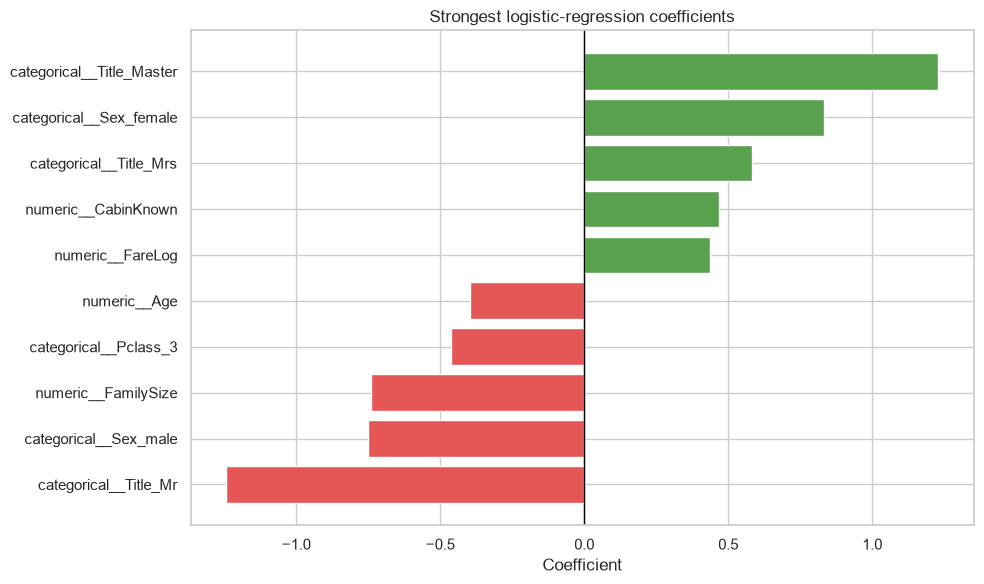

In [35]:
preprocessor = final_logistic.named_steps["preparation"]
feature_names = preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": final_logistic.named_steps["model"].coef_[0],
})
coefficients["Direction"] = np.where(coefficients["Coefficient"] > 0, "Toward survival", "Toward not surviving")
coefficients["Absolute coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Coefficient", ascending=False)
coefficients.to_csv(TABLE_DIR / "logistic_coefficients.csv", index=False)

top_survival = coefficients.head(5)[["Feature", "Coefficient"]]
top_non_survival = coefficients.tail(5).sort_values("Coefficient")[["Feature", "Coefficient"]]
print("Largest positive coefficients")
show_table(top_survival.round(3))
print("Largest negative coefficients")
show_table(top_non_survival.round(3))

plot_coefficients = pd.concat([top_non_survival, top_survival]).sort_values("Coefficient")
fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(plot_coefficients["Coefficient"] > 0, "#59A14F", "#E45756")
ax.barh(plot_coefficients["Feature"], plot_coefficients["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Strongest logistic-regression coefficients", xlabel="Coefficient", ylabel="")
save_show(fig, "13_logistic_coefficients.png")

In [36]:
validation_features = final_logistic.named_steps["feature_builder"].transform(X_validation)
error_examples = validation_features.copy()
error_examples.insert(0, "PassengerId", id_validation)
error_examples.insert(1, "Actual", y_validation)
error_examples.insert(2, "Prediction", logistic_predictions)
error_examples.insert(3, "SurvivalProbability", logistic_probabilities)
error_examples["ErrorType"] = np.select(
    [
        (error_examples["Actual"] == 0) & (error_examples["Prediction"] == 1),
        (error_examples["Actual"] == 1) & (error_examples["Prediction"] == 0),
    ],
    ["False positive", "False negative"],
    default="Correct",
)
false_positives = error_examples[error_examples["ErrorType"] == "False positive"].sort_values(
    "SurvivalProbability", ascending=False
).head(3)
false_negatives = error_examples[error_examples["ErrorType"] == "False negative"].sort_values(
    "SurvivalProbability", ascending=True
).head(3)
selected_errors = pd.concat([false_positives, false_negatives])
selected_errors.to_csv(TABLE_DIR / "selected_logistic_errors.csv", index=False)

error_counts = pd.Series({
    "False positives": int(((y_validation == 0) & (logistic_predictions == 1)).sum()),
    "False negatives": int(((y_validation == 1) & (logistic_predictions == 0)).sum()),
})
print(error_counts.to_string())
show_table(selected_errors[[
    "ErrorType", "PassengerId", "Actual", "Prediction", "SurvivalProbability",
    "Pclass", "Sex", "Age", "Title", "FamilySize", "CabinKnown",
]].round(3))

False positives    14
False negatives    17


,ErrorType,PassengerId,Actual,Prediction,SurvivalProbability,Pclass,Sex,Age,Title,FamilySize,CabinKnown
297,False positive,298,0,1,0.946,1,female,2.0,Miss,4,1
199,False positive,200,0,1,0.781,2,female,24.0,Miss,1,0
578,False positive,579,0,1,0.754,3,female,NaN,Mrs,2,0
271,False negative,272,1,0,0.033,3,male,25.0,Mr,1,0
570,False negative,571,1,0,0.064,2,male,62.0,Mr,1,0
804,False negative,805,1,0,0.075,3,male,27.0,Mr,1,0


## 6. Limitations and Plain-Language Conclusion

### Limitations

- The dataset is small: 712 rows were used for training and 179 for validation.
- Final selection partly depends on one held-out split; that validation set should not now be reused for tuning.
- Median imputation and `CabinKnown` simplify incomplete information.
- The available variables do not capture every circumstance that affected an individual passenger.
- The data are historical and observational. Sex, class, and title are associations in this event, not causal rules or fair criteria for modern decisions.
- Feature engineering was intentionally limited and no hyperparameter tuning was performed.

### Conclusion

Survival was strongly associated with sex and passenger class, while fare, family structure, age, title, and cabin-record availability added useful context. The final logistic-regression model correctly classified about 83% of the held-out passengers. It made 14 false-positive and 17 false-negative errors, showing that broad group patterns cannot explain every individual outcome. Logistic regression is a reasonable final choice because it combined solid validation performance, stable results, and clear interpretation for a small educational dataset.

The next CRISP-DM activity is deployment and communication: place this notebook and its saved outputs in the assignment repository, then use them in the README, Medium article, transcript PDF, and YouTube walkthrough.